# Week1-4:Evaluating the uncertainties of the model

Get 1D PDFs from the likelihood grid and MCMC chain

In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

%matplotlib inline

In [8]:
data_path = '../data/'

In [55]:
mvr_grid = np.loadtxt(data_path+"mvr_grid_Cas3.txt")
dvr_grid = np.loadtxt(data_path+"dvr_grid_Cas3.txt")
logL_grid = np.loadtxt(data_path+"logL_grid_Cas3.txt")

chain = np.loadtxt(data_path+'chain_Cas3.txt')

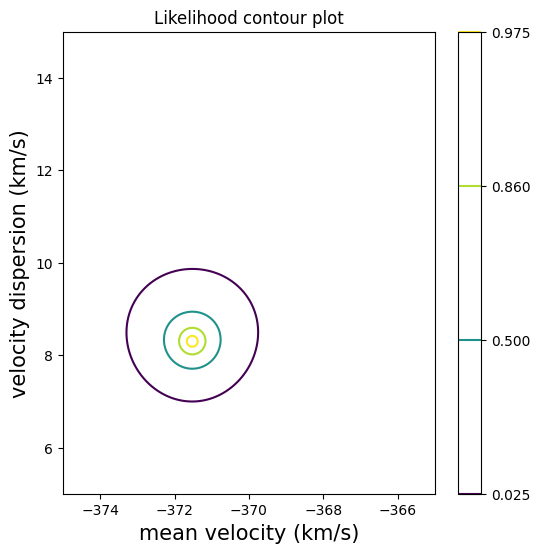

In [30]:
# This is the contour plot of Likelihood, we want it to be normalized to the maximum value
levels = np.array([0.025, 0.5, 0.86, 0.975])
plt.figure(figsize=(6,6))
contour = plt.contour(mvr_grid, dvr_grid, np.exp(logL_grid.T-np.max(logL_grid)), levels=levels)
cbar = plt.colorbar(contour)  # Add colorbar

plt.title('Likelihood contour plot')
plt.xlabel('mean velocity (km/s)', fontsize=15)
plt.ylabel('velocity dispersion (km/s)', fontsize=15)
plt.show()

In [31]:
# Now we sum up bins along each axis to get the marginalized pdfs for each parameter (边缘概率密度函数)

pdf_mvr = np.arange(len(mvr_grid))
pdf_dvr = np.arange(len(dvr_grid))

for i in range(len(mvr_grid)):

    pdf_mvr[i] = np.exp(logL_grid[i, :]-np.max(logL_grid)).sum()
    pdf_dvr[i] = np.exp(logL_grid[:, i]-np.max(logL_grid)).sum()


pdf_mvr = pdf_mvr/pdf_mvr.sum()
pdf_dvr = pdf_dvr/pdf_dvr.sum()

Text(0.5, 0, 'velocity dispersion (km/s)')

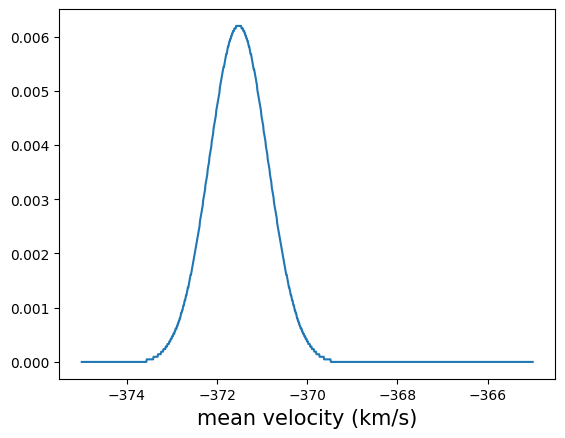

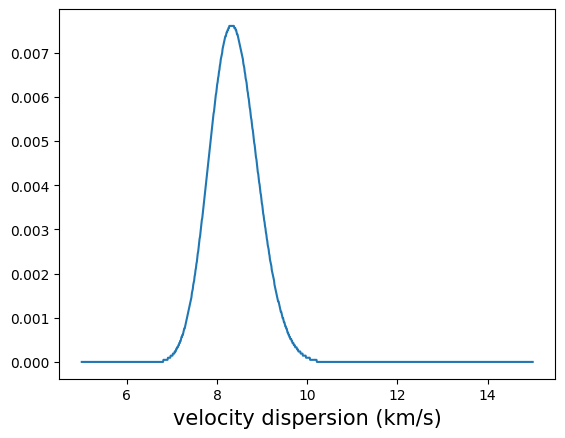

In [32]:
plt.figure()
plt.plot(mvr_grid, pdf_mvr, label='PDF of mean velocity')

plt.xlabel('mean velocity (km/s)', fontsize=15)


plt.figure()
plt.plot(dvr_grid, pdf_dvr, label='PDF of velocity dispersion')

plt.xlabel('velocity dispersion (km/s)', fontsize=15)


In [33]:
# Now we can get the 16th and 84th percentile of each PDFs
grid = np.arange(len(mvr_grid))
likelihood_mvr = np.zeros(len(grid))
likelihood_dvr = np.zeros(len(grid))


for i in range (len(grid)):

    ind = grid <= grid[i]

    likelihood_mvr[i] = pdf_mvr[ind].sum()
    likelihood_dvr[i] = pdf_dvr[ind].sum()

In [63]:
ind_16 =  likelihood_dvr >= 0.16
ind_84 =  likelihood_dvr >= 0.84
ind_50 =  likelihood_dvr >= 0.5

print ("%.1f"%dvr_grid[ind_16][0], "%.1f"%dvr_grid[ind_50][0], "%.1f"%dvr_grid[ind_84][0])


ind1 = pdf_dvr >= np.exp(-0.5)*pdf_dvr.max()
ind_max = np.argmax(pdf_dvr)
print ("%.1f"%dvr_grid[ind1][0],"%.1f"%dvr_grid[ind_max], "%.1f"%dvr_grid[ind1][-1])

7.9 8.4 8.9
7.8 8.3 8.9


<>:12: SyntaxWarning: invalid escape sequence '\s'
<>:13: SyntaxWarning: invalid escape sequence '\s'
<>:12: SyntaxWarning: invalid escape sequence '\s'
<>:13: SyntaxWarning: invalid escape sequence '\s'
/var/folders/sv/g85xms0x0cz4m76jsq8fh_wh0000gn/T/ipykernel_12818/4060441104.py:12: SyntaxWarning: invalid escape sequence '\s'
  plt.axvline(dvr_grid[ind1][0], color='orange', linestyle='dotted', label='peak-1$\sigma$: %.2f km/s'%dvr_grid[ind1][0])
/var/folders/sv/g85xms0x0cz4m76jsq8fh_wh0000gn/T/ipykernel_12818/4060441104.py:13: SyntaxWarning: invalid escape sequence '\s'
  plt.axvline(dvr_grid[ind1][-1], color='orange', linestyle='--', label='peak+1$\sigma$: %.2f km/s'%dvr_grid[ind1][-1])


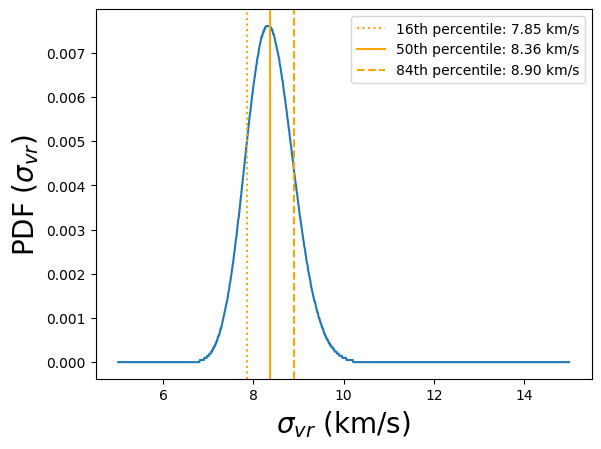

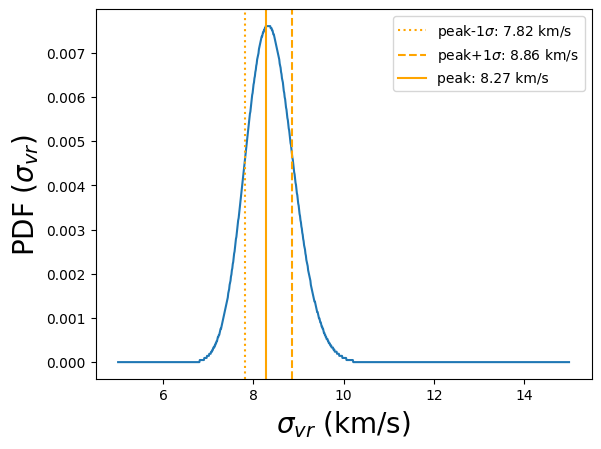

In [66]:
plt.figure()
plt.plot(dvr_grid, pdf_dvr)
plt.axvline(dvr_grid[ind_16][0], color='orange', linestyle='dotted', label='16th percentile: %.2f km/s'%dvr_grid[ind_16][0])
plt.axvline(dvr_grid[ind_50][0], color='orange', linestyle='-', label='50th percentile: %.2f km/s'%dvr_grid[ind_50][0])
plt.axvline(dvr_grid[ind_84][0], color='orange', linestyle='--', label='84th percentile: %.2f km/s'%dvr_grid[ind_84][0])
plt.xlabel (r'$\sigma_{vr}$ (km/s)', fontsize=20)
plt.ylabel (r'PDF ($\sigma_{vr}$)', fontsize=20)
plt.legend()

plt.figure()
plt.plot(dvr_grid, pdf_dvr)
plt.axvline(dvr_grid[ind1][0], color='orange', linestyle='dotted', label='peak-1$\sigma$: %.2f km/s'%dvr_grid[ind1][0])
plt.axvline(dvr_grid[ind1][-1], color='orange', linestyle='--', label='peak+1$\sigma$: %.2f km/s'%dvr_grid[ind1][-1])
plt.axvline(dvr_grid[ind_max], color='orange', linestyle='-',label='peak: %.2f km/s'%dvr_grid[ind_max])

plt.xlabel (r'$\sigma_{vr}$ (km/s)', fontsize=20)
plt.ylabel (r'PDF ($\sigma_{vr}$)', fontsize=20)
plt.legend()



Text(0, 0.5, 'PDF ($\\sigma_{vr}$)')

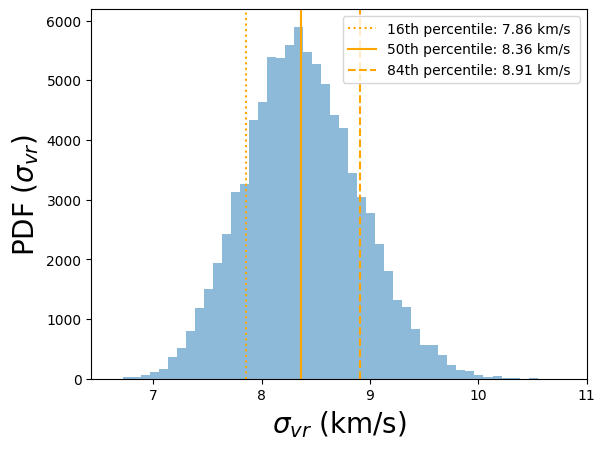

In [56]:
plt.figure()
plt.hist(chain[:,1], bins=50, alpha=0.5);
plt.axvline(np.percentile(chain[:,1], 16), color='orange', linestyle='dotted', label='16th percentile: %.2f km/s'%np.percentile(chain[:,1], 16))
plt.axvline(np.percentile(chain[:,1], 50), color='orange', linestyle='-', label='50th percentile: %.2f km/s '%np.percentile(chain[:,1], 50))
plt.axvline(np.percentile(chain[:,1], 84), color='orange', linestyle='--', label='84th percentile: %.2f km/s'%np.percentile(chain[:,1], 84))
plt.legend()
plt.xlabel (r'$\sigma_{vr}$ (km/s)', fontsize=20)
plt.ylabel (r'PDF ($\sigma_{vr}$)', fontsize=20)